In [ ]:
# !pip3 install pandas numpy matplotlib scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)

## Configuration

In [3]:
NAME     = "t_1500_3000"   # scheme name — matches the filenames
NODE_IDS = [0, 1, 2, 3, 4] # node IDs present in the experiment
DATA_DIR = "./data"

## Load node logs

In [4]:
traces = {}
for nid in NODE_IDS:
    path = f"{DATA_DIR}/node_{nid}_{NAME}.csv"
    df = pd.read_csv(path)
    df = df.sort_values("timestamp_usec").reset_index(drop=True)
    df["timestamp_sec"] = df["timestamp_usec"] / 1e6
    traces[nid] = df
    print(f"Node {nid}: {len(df)} events")

# Combine into one dataframe for cross-node queries
all_events = pd.concat(traces.values(), ignore_index=True).sort_values("timestamp_usec").reset_index(drop=True)
all_events.head(10)

Node 0: 4428 events
Node 1: 4319 events
Node 2: 4890 events
Node 3: 4161 events
Node 4: 4277 events


,node_id,timestamp_usec,event,term,leader_id,value,timestamp_sec
0,4,9192143062,starting,-1,-1,-1,9192.143062
1,4,9192146348,timeout,0,-1,0,9192.146348
2,4,9193036488,became_candidate,1,-1,0,9193.036488
3,4,9193039423,became_follower,2,0,0,9193.039423
4,4,9193041950,became_follower,3,0,0,9193.041950
5,4,9193550302,heartbeat,3,0,500951,9193.550302
6,4,9194051368,heartbeat,3,0,501083,9194.051368
7,4,9194552347,heartbeat,3,0,500966,9194.552347
8,4,9195134497,heartbeat,3,0,582166,9195.134497
9,4,9195553286,heartbeat,3,0,418758,9195.553286


## Identify crash terms

An `intentional_crash` event in term **T** means we should look for the next leader election in term **T+1**.
Detection time = `became_leader (T+1)` − `last heartbeat before timeout in term T` on the node that detected the crash.

In [5]:
crash_events = all_events[all_events["event"] == "intentional_crash"].copy()
print(f"Found {len(crash_events)} intentional crashes")
crash_events[["node_id", "timestamp_sec", "term", "leader_id"]]

Found 106 intentional crashes


,node_id,timestamp_sec,term,leader_id
125,4,9247.760271,4,-1
369,0,9292.796888,3,-1
596,3,9322.988299,6,-1
1012,1,9373.959401,5,-1
1227,0,9404.681054,7,-1
...,...,...,...,...
21073,0,12173.353636,117,-1
21524,3,12241.821267,121,-1
21549,4,12250.099757,122,-1
21561,2,12253.451442,120,-1


In [6]:
MAX_TERM_SEARCH = 10

records = []

for _, crash in crash_events.iterrows():
    crash_term = int(crash["term"])

    # --- Find became_leader in T+1, T+2, ... up to MAX_TERM_SEARCH ---
    leader_row    = None
    election_term = None
    for offset in range(1, MAX_TERM_SEARCH + 1):
        candidate_term = crash_term + offset
        leader_rows = all_events[
            (all_events["event"] == "became_leader") &
            (all_events["term"]  == candidate_term)
        ]
        if not leader_rows.empty:
            election_term = candidate_term
            leader_row = leader_rows.sort_values("timestamp_usec").iloc[0]
            if offset > 1:
                print(f"  [INFO] Crash term {crash_term}: leader found at term {election_term} "
                      f"(after {offset - 1} failed election(s))")
            break

    if leader_row is None:
        print(f"  [SKIP] Crash term {crash_term}: no became_leader within {MAX_TERM_SEARCH} terms — skipping")
        continue

    new_leader_id = int(leader_row["node_id"])
    t_leader      = leader_row["timestamp_sec"]

    # --- Find the last heartbeat before the timeout on the new leader's node ---
    # Accept timeouts in any term between crash_term and election_term (inclusive)
    node_trace = traces[new_leader_id]

    timeout_rows = node_trace[
        (node_trace["event"] == "timeout") &
        (node_trace["term"].between(crash_term, election_term))
    ]

    if timeout_rows.empty:
        print(f"  [WARN] No timeout found on node {new_leader_id} for terms {crash_term}->{election_term}")
        continue

    # Use the first timeout that precedes became_leader
    timeout_row = timeout_rows[
        timeout_rows["timestamp_usec"] < leader_row["timestamp_usec"]
    ].sort_values("timestamp_usec").iloc[0]

    t_timeout = timeout_row["timestamp_sec"]

    # Last heartbeat strictly before that first timeout
    hb_before = node_trace[
        (node_trace["event"]         == "heartbeat") &
        (node_trace["timestamp_usec"] < timeout_row["timestamp_usec"])
    ]

    if hb_before.empty:
        print(f"  [WARN] No heartbeat before timeout on node {new_leader_id} for crash term {crash_term}")
        continue

    last_hb   = hb_before.sort_values("timestamp_usec").iloc[-1]
    t_last_hb = last_hb["timestamp_sec"]

    detection_time_sec = t_leader - t_last_hb

    records.append({
        "crash_term":       crash_term,
        "election_term":    election_term,
        "failed_elections": election_term - crash_term - 1,
        "new_leader":       new_leader_id,
        "t_last_heartbeat": t_last_hb,
        "t_timeout":        t_timeout,
        "t_became_leader":  t_leader,
        "detection_sec":    detection_time_sec,
        "detection_ms":     detection_time_sec * 1000,
    })

results = pd.DataFrame(records)
print(f"\nSuccessfully measured {len(results)} crash-detection events")
results


  [INFO] Crash term 15: leader found at term 17 (after 1 failed election(s))
  [INFO] Crash term 26: leader found at term 28 (after 1 failed election(s))
  [INFO] Crash term 32: leader found at term 34 (after 1 failed election(s))
  [INFO] Crash term 36: leader found at term 38 (after 1 failed election(s))
  [INFO] Crash term 43: leader found at term 45 (after 1 failed election(s))
  [INFO] Crash term 54: leader found at term 56 (after 1 failed election(s))
  [INFO] Crash term 70: leader found at term 72 (after 1 failed election(s))
  [INFO] Crash term 73: leader found at term 76 (after 2 failed election(s))
  [INFO] Crash term 82: leader found at term 84 (after 1 failed election(s))
  [INFO] Crash term 90: leader found at term 93 (after 2 failed election(s))
  [INFO] Crash term 94: leader found at term 96 (after 1 failed election(s))
  [INFO] Crash term 108: leader found at term 110 (after 1 failed election(s))

Successfully measured 106 crash-detection events


,crash_term,election_term,failed_elections,new_leader,t_last_heartbeat,t_timeout,t_became_leader,detection_sec,detection_ms
0,4,5,0,1,9346.112734,9348.115269,9348.349589,2.236855,2236.855
1,3,4,0,4,9219.568743,9221.998114,9222.507469,2.938726,2938.726
2,6,7,0,0,9376.893403,9378.518158,9378.754719,1.861316,1861.316
3,5,6,0,3,9294.960181,9297.070143,9297.368195,2.408014,2408.014
4,7,8,0,2,9394.808546,9396.432429,9397.078520,2.269974,2269.974
...,...,...,...,...,...,...,...,...,...
101,117,118,0,4,12100.128029,12101.820940,12102.342629,2.214600,2214.600
102,121,122,0,4,12222.768715,12224.541029,12224.777496,2.008781,2008.781
103,122,123,0,3,12269.305556,12271.634600,12271.840769,2.535213,2535.213
104,120,121,0,3,12209.477038,12211.332109,12211.683862,2.206824,2206.824


## Summary statistics

In [7]:
desc = results["detection_ms"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])
print(f"Scheme: {NAME}")
print("\n--- Detection + replacement time (ms) ---")
print(desc.to_string())
print(f"\nMean:   {results['detection_ms'].mean():.1f} ms")
print(f"Median: {results['detection_ms'].median():.1f} ms")
print(f"p95:    {results['detection_ms'].quantile(0.95):.1f} ms")

print("\n--- Election cycles to successful leader (failed_elections = rounds before success) ---")
print(results["failed_elections"].value_counts().sort_index().rename("count").to_string())
print(f"\nMean failed elections per crash: {results['failed_elections'].mean():.2f}")
print(f"Max failed elections in one crash: {results['failed_elections'].max()}")


Scheme: t_1500_3000

--- Detection + replacement time (ms) ---
count     106.000000
mean     2389.876387
std       853.214490
min      1657.962000
25%      1900.201250
50%      2169.124000
75%      2397.345750
95%      4219.600250
max      6572.059000

Mean:   2389.9 ms
Median: 2169.1 ms
p95:    4219.6 ms

--- Election cycles to successful leader (failed_elections = rounds before success) ---
failed_elections
0    94
1    10
2     2

Mean failed elections per crash: 0.13
Max failed elections in one crash: 2


## Plots

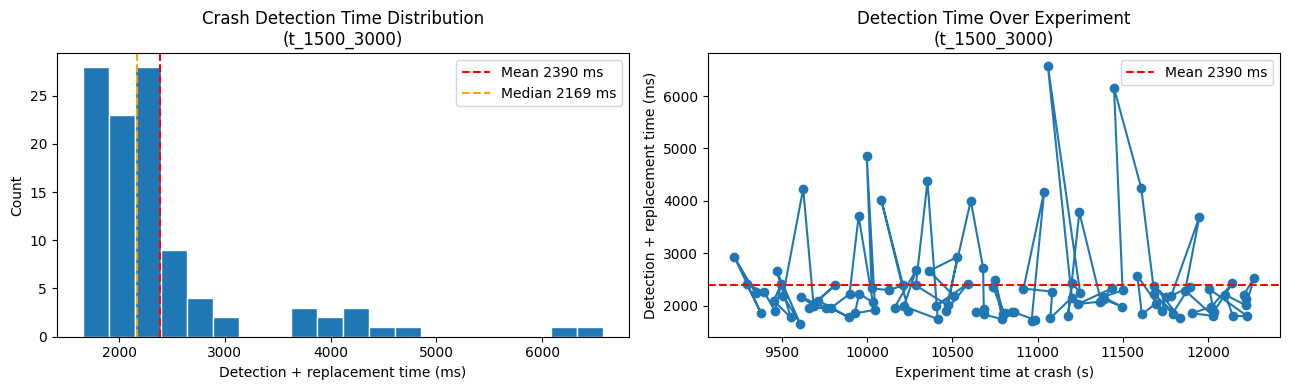

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Histogram ---
ax = axes[0]
ax.hist(results["detection_ms"], bins=20, edgecolor="white")
ax.axvline(results["detection_ms"].mean(),   color="red",    linestyle="--", label=f"Mean {results['detection_ms'].mean():.0f} ms")
ax.axvline(results["detection_ms"].median(), color="orange", linestyle="--", label=f"Median {results['detection_ms'].median():.0f} ms")
ax.set_xlabel("Detection + replacement time (ms)")
ax.set_ylabel("Count")
ax.set_title(f"Crash Detection Time Distribution\n({NAME})")
ax.legend()

# --- Over time (per crash) ---
ax = axes[1]
ax.plot(results["t_last_heartbeat"], results["detection_ms"], marker="o")
ax.axhline(results["detection_ms"].mean(), color="red", linestyle="--", label=f"Mean {results['detection_ms'].mean():.0f} ms")
ax.set_xlabel("Experiment time at crash (s)")
ax.set_ylabel("Detection + replacement time (ms)")
ax.set_title(f"Detection Time Over Experiment\n({NAME})")
ax.legend()

plt.tight_layout()
plt.show()

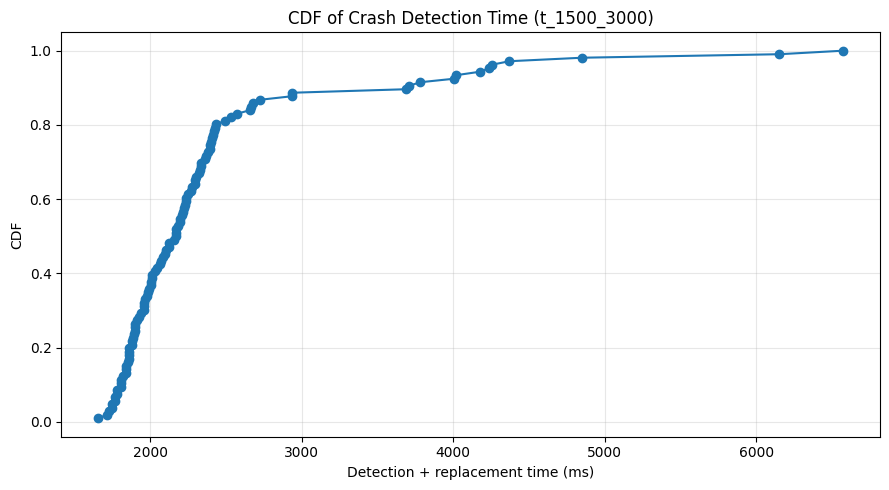

In [9]:
sorted_ms = np.sort(results["detection_ms"])
cdf = np.arange(1, len(sorted_ms) + 1) / len(sorted_ms)

plt.plot(sorted_ms, cdf, marker="o")
plt.xlabel("Detection + replacement time (ms)")
plt.ylabel("CDF")
plt.title(f"CDF of Crash Detection Time ({NAME})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Multi-scheme comparison

Configure the two sweeps below, then run the cells to compare Timeout vs Accrual schemes.

In [ ]:
# Timeout schemes: parameter is the base timeout T (ms)
# Files are expected at data/node_{n}_t_{T}_{2T}.csv
TIMEOUT_PARAMS = [
    (750,  1500),
    (1000, 2000),
    (1500, 3000),
    (2000, 4000),
]  # (T_ms, 2T_ms)

# Accrual schemes: parameter is the phi threshold
# Files are expected at data/node_{n}_a_{phi}.csv
ACCRUAL_PARAMS = [
    4.0,
    5.0,
    6.0,
    8.0,
]  # phi threshold values

def timeout_name(t, two_t):
    return f"t_{t}_{two_t}"

def accrual_name(phi):
    return f"a_{str(phi).replace('.', '_')}"


## Core analysis function

In [ ]:
def load_traces(name, node_ids, data_dir):
    traces = {}
    for nid in node_ids:
        path = f"{data_dir}/node_{nid}_{name}.csv"
        df = pd.read_csv(path)
        df = df.sort_values("timestamp_usec").reset_index(drop=True)
        df["timestamp_sec"] = df["timestamp_usec"] / 1e6
        traces[nid] = df
    return traces


def analyze_scheme(name, node_ids, data_dir, max_term_search=10):
    """Load traces for `name` and return a DataFrame of per-crash measurements."""
    try:
        traces = load_traces(name, node_ids, data_dir)
    except FileNotFoundError as e:
        print(f"  [SKIP] {name}: {e}")
        return pd.DataFrame()

    all_events = pd.concat(traces.values(), ignore_index=True).sort_values("timestamp_usec").reset_index(drop=True)
    crash_events = all_events[all_events["event"] == "intentional_crash"].copy()

    records = []
    for _, crash in crash_events.iterrows():
        crash_term = int(crash["term"])

        leader_row    = None
        election_term = None
        for offset in range(1, max_term_search + 1):
            candidate_term = crash_term + offset
            leader_rows = all_events[
                (all_events["event"] == "became_leader") &
                (all_events["term"]  == candidate_term)
            ]
            if not leader_rows.empty:
                election_term = candidate_term
                leader_row = leader_rows.sort_values("timestamp_usec").iloc[0]
                break

        if leader_row is None:
            continue

        new_leader_id = int(leader_row["node_id"])
        t_leader      = leader_row["timestamp_sec"]
        node_trace    = traces[new_leader_id]

        timeout_rows = node_trace[
            (node_trace["event"] == "timeout") &
            (node_trace["term"].between(crash_term, election_term))
        ]
        if timeout_rows.empty:
            continue

        timeout_row = timeout_rows[
            timeout_rows["timestamp_usec"] < leader_row["timestamp_usec"]
        ].sort_values("timestamp_usec").iloc[0]

        hb_before = node_trace[
            (node_trace["event"]         == "heartbeat") &
            (node_trace["timestamp_usec"] < timeout_row["timestamp_usec"])
        ]
        if hb_before.empty:
            continue

        last_hb   = hb_before.sort_values("timestamp_usec").iloc[-1]
        t_last_hb = last_hb["timestamp_sec"]

        detection_ms = (t_leader - t_last_hb) * 1000
        records.append({
            "crash_term":       crash_term,
            "election_term":    election_term,
            "failed_elections": election_term - crash_term - 1,
            "new_leader":       new_leader_id,
            "t_last_heartbeat": t_last_hb,
            "t_became_leader":  t_leader,
            "detection_ms":     detection_ms,
        })

    return pd.DataFrame(records)


def scheme_summary(df):
    """Return a dict of summary statistics for a scheme's result DataFrame."""
    if df.empty:
        return None
    ms = df["detection_ms"]
    n  = len(ms)
    mean = ms.mean()
    std  = ms.std()
    sem  = std / np.sqrt(n)          # standard error of the mean
    ci95 = 1.96 * sem                # 95% CI half-width
    return {
        "n":               n,
        "mean_ms":         mean,
        "std_ms":          std,
        "sem_ms":          sem,
        "ci95_ms":         ci95,
        "median_ms":       ms.median(),
        "p25_ms":          ms.quantile(0.25),
        "p75_ms":          ms.quantile(0.75),
        "p95_ms":          ms.quantile(0.95),
        "mean_failed_elections": df["failed_elections"].mean(),
        "pct_failed_elections":  (df["failed_elections"] > 0).mean() * 100,
    }


## Run sweep

In [ ]:
all_results   = {}   # name -> raw DataFrame
all_summaries = {}   # name -> summary dict

print("=== Timeout schemes ===")
for (t, two_t) in TIMEOUT_PARAMS:
    name = timeout_name(t, two_t)
    df   = analyze_scheme(name, NODE_IDS, DATA_DIR)
    all_results[name]   = df
    all_summaries[name] = scheme_summary(df)
    if all_summaries[name]:
        s = all_summaries[name]
        print(f"  {name:20s}  n={s['n']:3d}  mean={s['mean_ms']:7.1f} ms  ±{s['ci95_ms']:.1f} (95% CI)  "
              f"median={s['median_ms']:.1f}  failed_elections={s['mean_failed_elections']:.2f}")

print("\n=== Accrual schemes ===")
for phi in ACCRUAL_PARAMS:
    name = accrual_name(phi)
    df   = analyze_scheme(name, NODE_IDS, DATA_DIR)
    all_results[name]   = df
    all_summaries[name] = scheme_summary(df)
    if all_summaries[name]:
        s = all_summaries[name]
        print(f"  {name:20s}  n={s['n']:3d}  mean={s['mean_ms']:7.1f} ms  ±{s['ci95_ms']:.1f} (95% CI)  "
              f"median={s['median_ms']:.1f}  failed_elections={s['mean_failed_elections']:.2f}")


## Comparison plots

In [ ]:
from scipy import stats as scipy_stats

def prep_series(params, name_fn, label_fn):
    """Extract ordered (label, summary) pairs for a parameter sweep."""
    out = []
    for p in params:
        name = name_fn(p) if not isinstance(p, tuple) else name_fn(*p)
        s    = all_summaries.get(name)
        if s:
            lbl = label_fn(p) if not isinstance(p, tuple) else label_fn(*p)
            out.append((lbl, s))
    return out

t_series = prep_series(TIMEOUT_PARAMS, timeout_name, lambda t, two_t: t)
a_series = prep_series(ACCRUAL_PARAMS, accrual_name, lambda phi: phi)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Mean + 95% CI ────────────────────────────────────────────────────────────
ax = axes[0]
for series, marker, color, label in [
    (t_series, "o", "steelblue",  "Timeout"),
    (a_series, "s", "darkorange", "Accrual"),
]:
    if not series:
        continue
    xs    = [x for x, _ in series]
    means = [s["mean_ms"]  for _, s in series]
    ci95  = [s["ci95_ms"]  for _, s in series]
    ax.errorbar(xs, means, yerr=ci95, marker=marker, color=color,
                capsize=5, linewidth=1.5, label=f"{label} (95% CI)")

ax.set_xlabel("Parameter value  (T in ms for Timeout, φ for Accrual)")
ax.set_ylabel("Mean detection + replacement time (ms)")
ax.set_title("Mean Detection Time vs Parameter")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Median + IQR ─────────────────────────────────────────────────────────────
ax = axes[1]
for series, marker, color, label in [
    (t_series, "o", "steelblue",  "Timeout"),
    (a_series, "s", "darkorange", "Accrual"),
]:
    if not series:
        continue
    xs      = [x for x, _ in series]
    medians = [s["median_ms"] for _, s in series]
    p25     = [s["p25_ms"]    for _, s in series]
    p75     = [s["p75_ms"]    for _, s in series]
    yerr_lo = [m - lo for m, lo in zip(medians, p25)]
    yerr_hi = [hi - m for m, hi in zip(medians, p75)]
    ax.errorbar(xs, medians, yerr=[yerr_lo, yerr_hi], marker=marker, color=color,
                capsize=5, linewidth=1.5, label=f"{label} (IQR)")

ax.set_xlabel("Parameter value  (T in ms for Timeout, φ for Accrual)")
ax.set_ylabel("Median detection + replacement time (ms)")
ax.set_title("Median Detection Time vs Parameter (IQR error bars)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Timeout vs Accrual — Detection Time Comparison")
plt.tight_layout()
plt.show()


In [ ]:
# ── CDF overlay: all schemes on one plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

cmap_t = plt.cm.Blues
cmap_a = plt.cm.Oranges

for ax, params, name_fn, label_fn, cmap, scheme_label in [
    (axes[0], TIMEOUT_PARAMS, timeout_name, lambda t, two_t: f"T={t} ms",  cmap_t, "Timeout"),
    (axes[1], ACCRUAL_PARAMS, accrual_name, lambda phi: f"φ={phi}",        cmap_a, "Accrual"),
]:
    valid = [(p, name_fn(*p) if isinstance(p, tuple) else name_fn(p)) for p in params]
    valid = [(p, n) for p, n in valid if not all_results.get(n, pd.DataFrame()).empty]
    colors = [cmap(0.4 + 0.5 * i / max(len(valid) - 1, 1)) for i in range(len(valid))]

    for (p, name), color in zip(valid, colors):
        ms     = np.sort(all_results[name]["detection_ms"].values)
        cdf    = np.arange(1, len(ms) + 1) / len(ms)
        lbl    = label_fn(*p) if isinstance(p, tuple) else label_fn(p)
        ax.plot(ms, cdf, color=color, linewidth=1.8, label=lbl)

    ax.set_xlabel("Detection + replacement time (ms)")
    ax.set_ylabel("CDF")
    ax.set_title(f"{scheme_label} schemes")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("CDF of Detection Time per Scheme")
plt.tight_layout()
plt.show()


In [ ]:
# ── Failed elections comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean failed elections vs parameter
ax = axes[0]
for series, marker, color, label in [
    (t_series, "o", "steelblue",  "Timeout"),
    (a_series, "s", "darkorange", "Accrual"),
]:
    if not series:
        continue
    xs  = [x for x, _ in series]
    ys  = [s["mean_failed_elections"] for _, s in series]
    ax.plot(xs, ys, marker=marker, color=color, linewidth=1.5, label=label)

ax.set_xlabel("Parameter value")
ax.set_ylabel("Mean failed elections per crash")
ax.set_title("Failed Elections Before Success")
ax.legend()
ax.grid(True, alpha=0.3)

# % of crashes that required ≥1 failed election
ax = axes[1]
for series, marker, color, label in [
    (t_series, "o", "steelblue",  "Timeout"),
    (a_series, "s", "darkorange", "Accrual"),
]:
    if not series:
        continue
    xs  = [x for x, _ in series]
    ys  = [s["pct_failed_elections"] for _, s in series]
    ax.plot(xs, ys, marker=marker, color=color, linewidth=1.5, label=label)

ax.set_xlabel("Parameter value")
ax.set_ylabel("% of crashes with ≥1 failed election")
ax.set_title("Fraction of Crashes Requiring Re-election")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Election Success Rate")
plt.tight_layout()
plt.show()


In [ ]:
# ── Box plots: one box per scheme, side-by-side Timeout vs Accrual ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, params, name_fn, label_fn, color, scheme_label in [
    (axes[0], TIMEOUT_PARAMS, timeout_name, lambda t, two_t: f"T={t}",  "steelblue",  "Timeout"),
    (axes[1], ACCRUAL_PARAMS, accrual_name, lambda phi: f"φ={phi}",     "darkorange", "Accrual"),
]:
    groups  = []
    xlabels = []
    for p in params:
        name = name_fn(*p) if isinstance(p, tuple) else name_fn(p)
        df   = all_results.get(name, pd.DataFrame())
        if not df.empty:
            groups.append(df["detection_ms"].values)
            lbl = label_fn(*p) if isinstance(p, tuple) else label_fn(p)
            xlabels.append(lbl)

    if groups:
        bp = ax.boxplot(groups, patch_artist=True, notch=True,
                        medianprops=dict(color="black", linewidth=2))
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        ax.set_xticks(range(1, len(xlabels) + 1))
        ax.set_xticklabels(xlabels)

    ax.set_xlabel("Parameter")
    ax.set_ylabel("Detection + replacement time (ms)")
    ax.set_title(f"{scheme_label} schemes")
    ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Detection Time Distribution per Scheme (notched box = 95% CI on median)")
plt.tight_layout()
plt.show()


## Summary table

In [ ]:
rows = []
for (t, two_t) in TIMEOUT_PARAMS:
    name = timeout_name(t, two_t)
    s    = all_summaries.get(name)
    if s:
        rows.append({"scheme": "Timeout", "param": t, "name": name, **s})

for phi in ACCRUAL_PARAMS:
    name = accrual_name(phi)
    s    = all_summaries.get(name)
    if s:
        rows.append({"scheme": "Accrual", "param": phi, "name": name, **s})

summary_table = pd.DataFrame(rows).set_index(["scheme", "param"])
summary_table[["name", "n", "mean_ms", "ci95_ms", "median_ms",
               "p25_ms", "p75_ms", "p95_ms",
               "mean_failed_elections", "pct_failed_elections"]].round(1)
